In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data_macro.csv', sep=';')

In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [5]:
df['GAP'] = pd.to_numeric(df['GAP'], errors='coerce')
df['INF'] = pd.to_numeric(df['INF'], errors='coerce')
df['IR3M'] = pd.to_numeric(df['IR3M'], errors='coerce')

In [6]:
df = df.dropna(subset=['GAP', 'INF', 'IR3M']).reset_index(drop=True)

In [7]:
print(df.head())
print(f"Nombre total d'observations : {len(df)}")

        Date  GAP       INF      IR3M
0 1992-04-01 -2.9  2.062027  6.589333
1 1992-07-01 -3.1  1.702226  5.261500
2 1992-10-01 -3.0  1.813012  7.490000
3 1993-01-01 -2.8  2.030083  6.332500
4 1993-04-01 -2.5  1.745995  5.160000
Nombre total d'observations : 132


In [8]:
corr = df[['GAP', 'INF', 'IR3M']].corr()
print(corr)

           GAP       INF      IR3M
GAP   1.000000  0.251167  0.216989
INF   0.251167  1.000000  0.033723
IR3M  0.216989  0.033723  1.000000


In [9]:
from statsmodels.tsa.api import VAR

In [10]:
data = df[['GAP', 'INF', 'IR3M']]

In [11]:
model = VAR(data)
results = model.fit(maxlags=2)

In [12]:
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 18, Nov, 2025
Time:                     18:25:52
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -3.71394
Nobs:                     130.000    HQIC:                  -3.98894
Log likelihood:          -260.871    FPE:                  0.0153468
AIC:                     -4.17716    Det(Omega_mle):       0.0131126
--------------------------------------------------------------------
Results for equation GAP
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.086198         0.145950            0.591           0.555
L1.GAP          1.134024         0.086106           13.170           0.000
L1.INF         -0.006772         0.134657           -0.050           0.960
L1.IR3M    

In [13]:
forecast = results.forecast(data.values[-results.k_ar:], steps=12)

In [14]:
forecast_df = pd.DataFrame(forecast, columns=['GAP', 'INF', 'IR3M'])
print(forecast_df)

         GAP       INF      IR3M
0  -0.574000  2.160212  2.728557
1  -0.521467  2.091454  2.706800
2  -0.406919  2.038832  2.724364
3  -0.278285  2.006449  2.751277
4  -0.162114  1.988201  2.774465
5  -0.069166  1.977240  2.789645
6  -0.000699  1.968934  2.796604
7   0.046652  1.961017  2.796684
8   0.077759  1.952856  2.791554
9   0.097328  1.944658  2.782719
10  0.109196  1.936907  2.771378
11  0.116186  1.930051  2.758432


In [15]:
last_period = df['Date'].dropna().iloc[-1]
future_dates = pd.date_range(last_period, periods=13, freq='QE')[1:]
forecast_df['Date'] = future_dates
print(forecast_df)

         GAP       INF      IR3M       Date
0  -0.574000  2.160212  2.728557 2025-06-30
1  -0.521467  2.091454  2.706800 2025-09-30
2  -0.406919  2.038832  2.724364 2025-12-31
3  -0.278285  2.006449  2.751277 2026-03-31
4  -0.162114  1.988201  2.774465 2026-06-30
5  -0.069166  1.977240  2.789645 2026-09-30
6  -0.000699  1.968934  2.796604 2026-12-31
7   0.046652  1.961017  2.796684 2027-03-31
8   0.077759  1.952856  2.791554 2027-06-30
9   0.097328  1.944658  2.782719 2027-09-30
10  0.109196  1.936907  2.771378 2027-12-31
11  0.116186  1.930051  2.758432 2028-03-31


In [16]:
import matplotlib.pyplot as plt

In [17]:
variables = ['GAP', 'INF', 'IR3M']

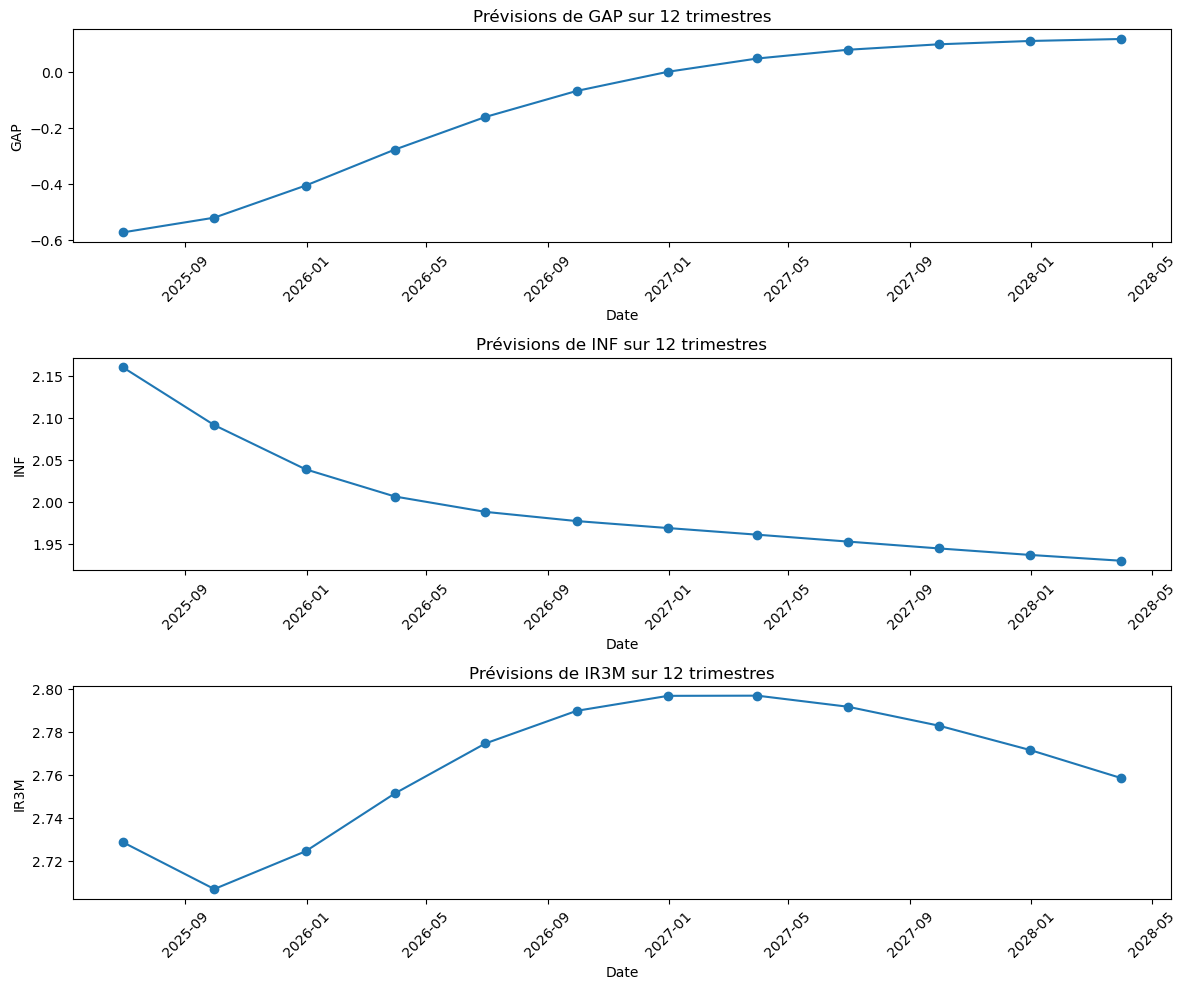

In [18]:
plt.figure(figsize=(12, 10))

for i, var in enumerate(variables, 1):
    plt.subplot(3, 1, i)
    plt.plot(forecast_df['Date'], forecast_df[var], marker='o')
    plt.title(f'Prévisions de {var} sur 12 trimestres')
    plt.xlabel('Date')
    plt.ylabel(var)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()